ARTI308 - Machine Learning

# Logistic Regression Assignment  

In this assignment we will be working with a fake advertising data set, indicating whether or not a particular internet user clicked on an Advertisement. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.

This data set contains the following features:

* 'Daily Time Spent on Site': consumer time on site in minutes
* 'Age': cutomer age in years
* 'Area Income': Avg. Income of geographical area of consumer
* 'Daily Internet Usage': Avg. minutes a day consumer is on the internet
* 'Ad Topic Line': Headline of the advertisement
* 'City': City of consumer
* 'Male': Whether or not consumer was male
* 'Country': Country of consumer
* 'Timestamp': Time at which consumer clicked on Ad or closed window
* 'Clicked on Ad': 0 or 1 indicated clicking on Ad

## Import Libraries

**Import a few libraries you think you'll need (Or just import them as you go along!)**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Get the Data
**Read in the advertising.csv file and set it to a data frame called ad_data.**

In [5]:
ad_data = pd.read_csv('advertising.csv')

**Check the head of ad_data**

In [6]:
ad_data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


** Use info and describe() on ad_data**

In [7]:
ad_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


In [8]:
ad_data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


## Exploratory Data Analysis

Let's use seaborn to explore the data!

Try recreating the plots shown below!

** Create a histogram of the Age**

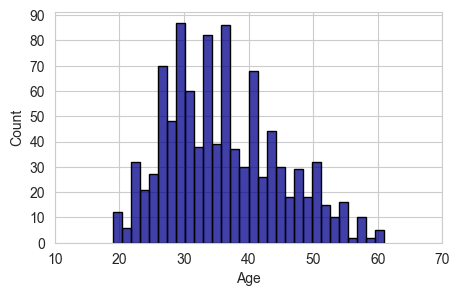

In [15]:

plt.figure(figsize=(5,3))

sns.histplot(ad_data['Age'], bins=30, color='darkblue'
            ,  edgecolor='black',    linewidth=1 ) 

plt.xticks([10,20,30,40,50,60,70])
plt.yticks([0,10,20,30,40,50,60,70,80,90])

plt.xlabel("Age")
plt.grid(True)

plt.show()

**Create a jointplot showing Area Income versus Age.**

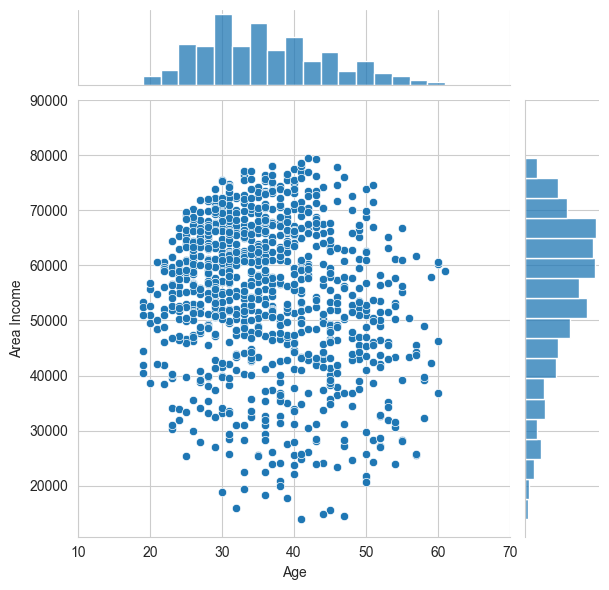

In [21]:
g = sns.jointplot(
    x='Age',
    y='Area Income',
    data=ad_data,
    height=6
)

g.ax_joint.set_xticks([10,20,30,40,50,60,70])
g.ax_joint.set_yticks([20000,30000,40000,50000,60000,70000,80000,90000])

g.ax_joint.set_xlabel("Age")
g.ax_joint.set_ylabel("Area Income")

g.ax_joint.grid(True)

**Create a jointplot showing the kde distributions of Daily Time spent on site vs. Age.**

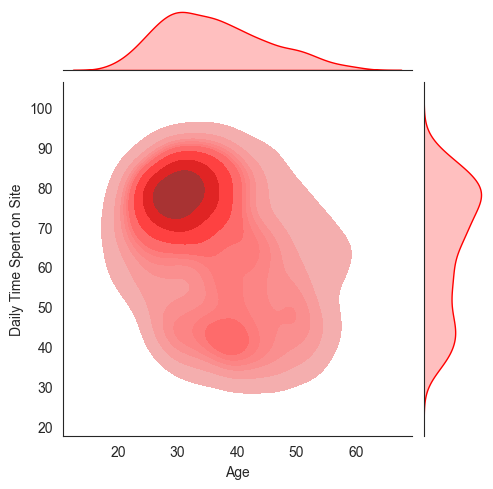

In [28]:
sns.set_style("white"),

g = sns.jointplot(
    x='Age',
    y='Daily Time Spent on Site',
    data=ad_data,
    kind='kde',     
    fill=True, 
    color='red' ,    
    height=5
)

** Create a jointplot of 'Daily Time Spent on Site' vs. 'Daily Internet Usage'**

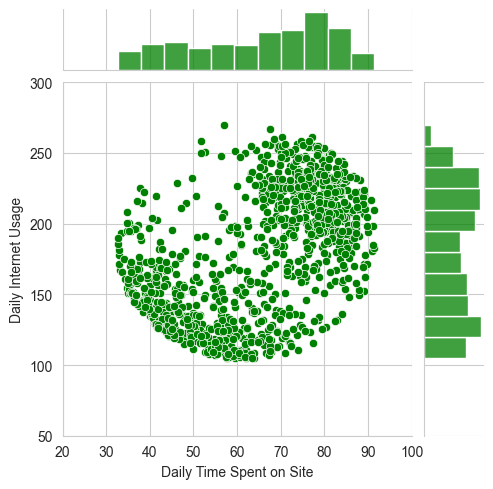

In [34]:
sns.set_style("whitegrid") 
g=sns.jointplot(
    x='Daily Time Spent on Site',
    y='Daily Internet Usage',
    color='green',
    data=ad_data,
height= 5
)
g.ax_joint.set_xticks([20,30,40,50,60,70,80,90,100])
g.ax_joint.set_yticks([50,100,150,200,250,300])

** Finally, create a pairplot with the hue defined by the 'Clicked on Ad' column feature.**

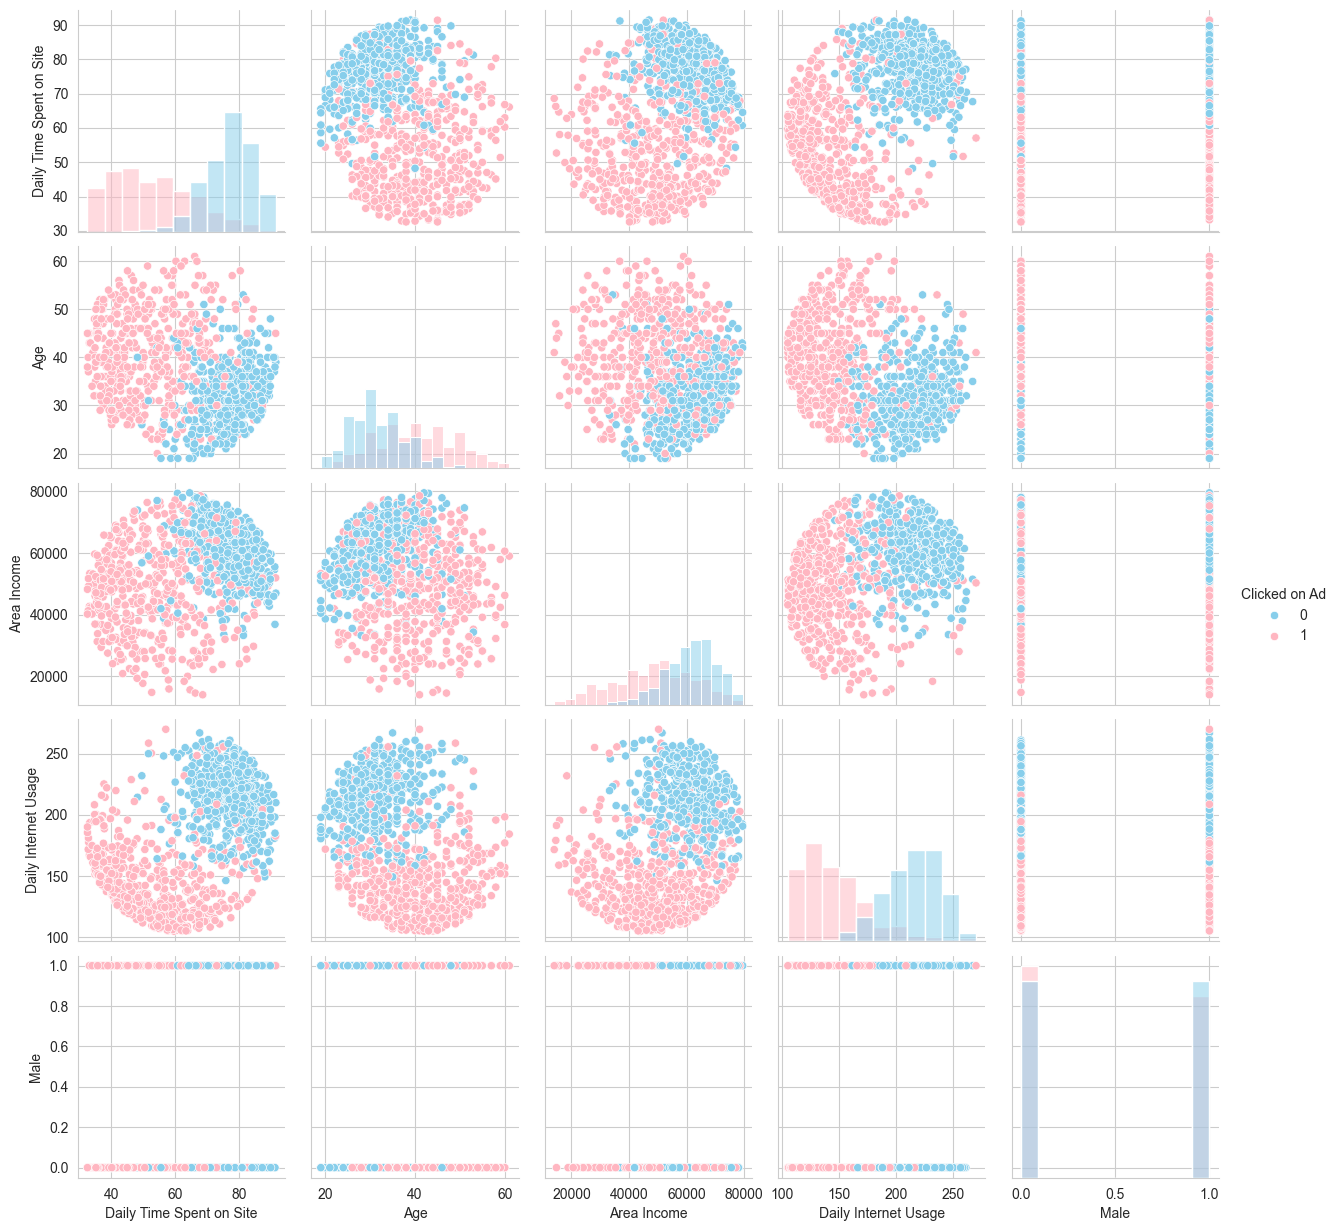

In [44]:
sns.pairplot(ad_data, hue='Clicked on Ad',
              palette=['skyblue','lightpink'],
              diag_kind='hist')


# Logistic Regression

Now it's time to do a train test split, and train our model!

You'll have the freedom here to choose columns that you want to train on!

** Split the data into training set and testing set using train_test_split**

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X = ad_data[['Daily Time Spent on Site',
             'Age',
             'Area Income',
             'Daily Internet Usage',
             'Male']]
y = ad_data['Clicked on Ad']


In [47]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101)

** Train and fit a logistic regression model on the training set.**

In [48]:
from sklearn.linear_model import LogisticRegression


In [65]:

logmodel = LogisticRegression(max_iter=1000)  
logmodel.fit(X_train, y_train)

params = logmodel.get_params()

print(f"LogisticRegression({params})")

LogisticRegression({'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False})


## Predictions and Evaluations
** Now predict values for the testing data.**

In [66]:
predictions = logmodel.predict(X_test)

** Create a classification report for the model.**

In [67]:
from sklearn.metrics import classification_report

In [72]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       157
           1       0.99      0.97      0.98       143

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



## Great Job!